# ASSIGNMENT 16 - RECOMMENDATION SYSTEM

In [1]:
# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries (for EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
# Load the anime dataset
df = pd.read_csv("anime.csv")

# Display first few rows
print(df.head())

# Check dataset structure
print(df.info())


   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  

In [3]:
# Check for missing values
print(df.isnull().sum())

# Drop rows where important columns are missing
df.dropna(subset=['name', 'genre', 'rating'], inplace=True)

# Fill missing episode counts with median
df['episodes'] = df['episodes'].replace('Unknown', np.nan)
df['episodes'] = df['episodes'].astype(float)
df['episodes'].fillna(df['episodes'].median(), inplace=True)

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)


anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


C:\Users\Jawad\AppData\Local\Temp\ipykernel_10368\3875457435.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['episodes'].fillna(df['episodes'].median(), inplace=True)


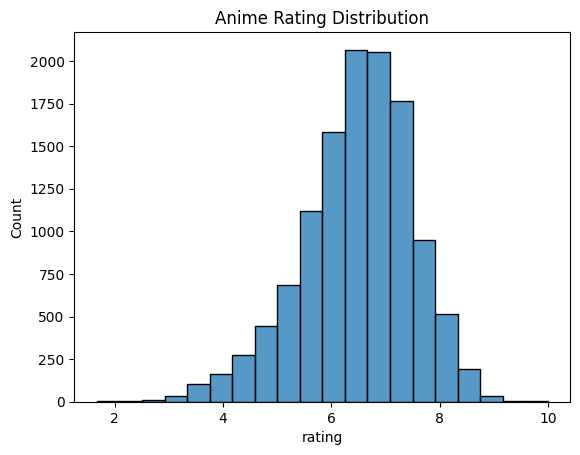

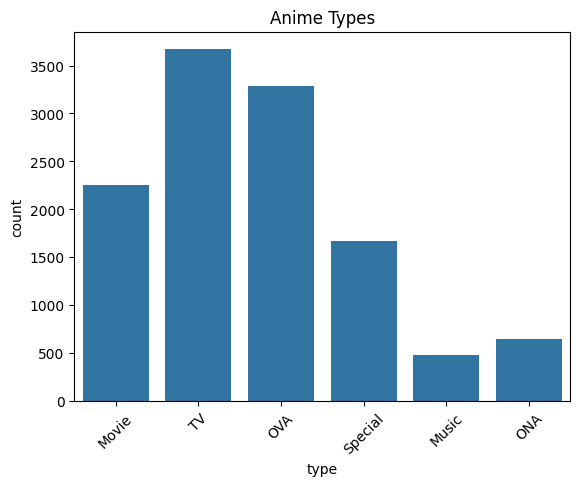

In [4]:
# Distribution of ratings
plt.figure()
sns.histplot(df['rating'], bins=20)
plt.title("Anime Rating Distribution")
plt.show()

# Anime types count
plt.figure()
sns.countplot(x='type', data=df)
plt.title("Anime Types")
plt.xticks(rotation=45)
plt.show()


In [5]:
# Convert genres to TF-IDF vectors
tfidf = TfidfVectorizer(stop_words='english')

genre_tfidf = tfidf.fit_transform(df['genre'])


In [6]:
# Select numerical features
num_features = df[['rating', 'episodes', 'members']]

# Normalize using MinMaxScaler
scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(num_features)


In [7]:
# Combine TF-IDF genre vectors with numerical features
from scipy.sparse import hstack

feature_matrix = hstack([genre_tfidf, num_scaled])


In [8]:
# Compute cosine similarity matrix
cosine_sim = cosine_similarity(feature_matrix, feature_matrix)


In [9]:
def recommend_anime(anime_name, top_n=10, similarity_threshold=0.3):
    """
    Recommend similar anime based on cosine similarity
    """
    if anime_name not in df['name'].values:
        return "Anime not found in dataset."

    # Get index of the anime
    idx = df[df['name'] == anime_name].index[0]

    # Get similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Filter based on threshold
    filtered_scores = [
        score for score in similarity_scores
        if score[1] >= similarity_threshold and score[0] != idx
    ]

    # Get top recommendations
    top_scores = filtered_scores[:top_n]

    # Fetch anime names
    recommendations = df.iloc[[i[0] for i in top_scores]][
        ['name', 'genre', 'rating']
    ]

    return recommendations


In [10]:
# Recommend anime similar to "Steins;Gate"
recommendations = recommend_anime("Steins;Gate", top_n=5, similarity_threshold=0.4)
print(recommendations)


                                                   name  \
59           Steins;Gate Movie: Fuka Ryouiki no Déjà vu   
126               Steins;Gate: Oukoubakko no Poriomania   
196   Steins;Gate: Kyoukaimenjou no Missing Link - D...   
5124                                      Under the Dog   
493                                     Higashi no Eden   

                                                  genre  rating  
59                                     Sci-Fi, Thriller    8.61  
126                                    Sci-Fi, Thriller    8.46  
196                                    Sci-Fi, Thriller    8.34  
5124                           Action, Sci-Fi, Thriller    6.55  
493   Action, Comedy, Drama, Mystery, Romance, Sci-F...    8.03  


In [11]:
# Low threshold (more recommendations)
print(recommend_anime("Steins;Gate", similarity_threshold=0.2))

# High threshold (more strict)
print(recommend_anime("Steins;Gate", similarity_threshold=0.6))


                                                   name  \
59           Steins;Gate Movie: Fuka Ryouiki no Déjà vu   
126               Steins;Gate: Oukoubakko no Poriomania   
196   Steins;Gate: Kyoukaimenjou no Missing Link - D...   
5124                                      Under the Dog   
493                                     Higashi no Eden   
2518                                        Ibara no Ou   
238                                          Gankutsuou   
5523                                       Loups=Garous   
36                                 Fate/Zero 2nd Season   
250                                   Zankyou no Terror   

                                                  genre  rating  
59                                     Sci-Fi, Thriller    8.61  
126                                    Sci-Fi, Thriller    8.46  
196                                    Sci-Fi, Thriller    8.34  
5124                           Action, Sci-Fi, Thriller    6.55  
493   Action, Comedy

"""
Observations:
1. Genre-based similarity dominates recommendations.
2. Popular anime (high members) may bias results.
3. Cosine similarity works well for textual features.

Possible Improvements:
- Add user rating matrix (Collaborative Filtering)
- Apply dimensionality reduction (PCA)
- Weight genres higher than popularity
- Hybrid recommendation (content + collaborative)
"""
